# Face Recognition Pipeline

Deep learning-based face recognition with YuNet + ArcFace.

**Standard Pipeline:**
1. YuNet detect -> bbox + 5 landmarks
2. Align face on original image
3. Convert aligned face to RGB
4. Resize to 112x112
5. ArcFace inference -> embedding
6. L2 normalize -> cosine similarity

## 1. Imports

In [112]:
from pathlib import Path
from PIL import Image
from urllib.request import urlretrieve
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
import onnx
import onnxruntime as ort

## 2. Configuration & Constants

In [113]:
# Dataset & cache paths
DATASET_ROOT = Path("datasource_v2")
CACHE_FILE = Path("datasource_v2_arcface_features.npz")

# File extensions to process
VALID_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}

# Image sizes (ArcFace standard: 112x112)
FACE_ALIGNMENT_SIZE = (112, 112)
EMBEDDING_DIM = 512

# Gallery configuration
GALLERY_IMAGES_PER_PERSON = 20

# Device (CPU/CUDA)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# YuNet face detection & landmark model
YUNET_MODEL_PATH = Path("face_detection_yunet_2023mar.onnx")
YUNET_MODEL_URL = (
    "https://github.com/opencv/opencv_zoo/raw/main/"
    "models/face_detection_yunet/face_detection_yunet_2023mar.onnx"
)

# ArcFace embedding model (stable mirrors)
ARCFACE_MODEL_PATH = Path("arcfaceresnet100-8.onnx")
ARCFACE_MODEL_URLS = [
    "https://github.com/onnx/models/raw/main/validated/vision/body_analysis/arcface/model/arcfaceresnet100-8.onnx",
    "https://huggingface.co/onnxmodelzoo/arcfaceresnet100-8/resolve/main/arcfaceresnet100-8.onnx",
]

print(f"Device: {DEVICE}")
print(f"Dataset root: {DATASET_ROOT}")
print(f"Cache file: {CACHE_FILE}")
print(f"Face alignment size: {FACE_ALIGNMENT_SIZE}")
print(f"Embedding dimension: {EMBEDDING_DIM}")
print(f"ArcFace model path: {ARCFACE_MODEL_PATH}")

Device: cpu
Dataset root: datasource_v2
Cache file: datasource_v2_arcface_features.npz
Face alignment size: (112, 112)
Embedding dimension: 512
ArcFace model path: arcfaceresnet100-8.onnx


## 3. Helper Functions - File & Model Management

In [114]:
def ensure_file(file_path, url_or_urls, min_size_bytes=10000):
    """Download a file if missing/invalid. Supports one URL or a list of URLs."""
    if file_path.exists() and file_path.stat().st_size >= min_size_bytes:
        return file_path

    urls = url_or_urls if isinstance(url_or_urls, (list, tuple)) else [url_or_urls]
    last_error = None

    for url in urls:
        try:
            if file_path.exists():
                file_path.unlink()

            print(f"Downloading {file_path.name} from: {url}")
            urlretrieve(url, str(file_path))

            if file_path.stat().st_size < min_size_bytes:
                raise RuntimeError(
                    f"Downloaded file too small ({file_path.stat().st_size} bytes)"
                )

            print(f"Downloaded {file_path.name} ({file_path.stat().st_size // 1024} KB)")
            return file_path
        except Exception as exc:
            last_error = exc
            print(f"Failed from this URL: {exc}")

    raise RuntimeError(f"Could not download {file_path.name} from all provided URLs") from last_error


def read_image_bgr(image_path):
    """Read image from path safely (handles non-ASCII filenames on Windows)."""
    data = np.fromfile(str(image_path), dtype=np.uint8)
    if data.size == 0:
        return None
    return cv2.imdecode(data, cv2.IMREAD_COLOR)

## 3B. Face Alignment (Using Eye Landmarks)

In [115]:
def align_face_on_original(image_bgr, landmarks, output_size=FACE_ALIGNMENT_SIZE):
    """
    Align face on the original image using 5-point landmarks.

    Args:
        image_bgr: Original BGR image
        landmarks: ndarray shape (5, 2), absolute pixel coords in original image
        output_size: target face size (112, 112)

    Returns:
        aligned_bgr: aligned face crop
    """
    # Canonical ArcFace 5-point template for 112x112
    dst = np.array(
        [
            [38.2946, 51.6963],
            [73.5318, 51.5014],
            [56.0252, 71.7366],
            [41.5493, 92.3655],
            [70.7299, 92.2041],
        ],
        dtype=np.float32,
    )

    src = landmarks.astype(np.float32)
    matrix, _ = cv2.estimateAffinePartial2D(src, dst, method=cv2.LMEDS)
    if matrix is None:
        return None

    aligned = cv2.warpAffine(
        image_bgr,
        matrix,
        output_size,
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=0,
    )
    return aligned

## 4. Load Embedding Model (ArcFace)

In [116]:
def load_arcface_model():
    """Load ArcFace model (ResNet100) from ONNX for face embedding."""
    ensure_file(ARCFACE_MODEL_PATH, ARCFACE_MODEL_URLS, min_size_bytes=5_000_000)

    providers = ["CPUExecutionProvider"]
    if DEVICE.type == "cuda":
        providers = ["CUDAExecutionProvider", "CPUExecutionProvider"]

    sess = ort.InferenceSession(str(ARCFACE_MODEL_PATH), providers=providers)
    input_name = sess.get_inputs()[0].name
    output_name = sess.get_outputs()[0].name
    input_shape = sess.get_inputs()[0].shape

    print(f"ONNX Runtime providers: {sess.get_providers()}")
    print(f"ArcFace input shape: {input_shape}")
    print(f"ArcFace input name: {input_name}")
    print(f"ArcFace output name: {output_name}")

    return sess, input_name, output_name


def extract_embedding_arcface(face_aligned_bgr, arcface_session, input_name, output_name):
    """
    Standard ArcFace preprocess and inference.

    Steps:
    1) BGR -> RGB
    2) Resize -> 112x112
    3) Normalize to [-1, 1]
    4) ArcFace inference
    5) L2 normalize embedding
    """
    face_rgb = cv2.cvtColor(face_aligned_bgr, cv2.COLOR_BGR2RGB)
    face_rgb = cv2.resize(face_rgb, (112, 112), interpolation=cv2.INTER_AREA)
    face_rgb = face_rgb.astype(np.float32) / 255.0
    face_rgb = (face_rgb - 0.5) / 0.5

    face_input = np.transpose(face_rgb, (2, 0, 1))[np.newaxis, :].astype(np.float32)
    embedding = arcface_session.run([output_name], {input_name: face_input})[0][0]

    # L2 normalization for cosine similarity
    embedding = embedding / (np.linalg.norm(embedding) + 1e-8)
    return embedding.astype(np.float32)


arcface_session, arcface_input_name, arcface_output_name = load_arcface_model()
print("ArcFace embedding model ready")

ONNX Runtime providers: ['CPUExecutionProvider']
ArcFace input shape: [1, 3, 112, 112]
ArcFace input name: data
ArcFace output name: fc1
ArcFace embedding model ready


## 5. Load YuNet Face Detector

In [117]:
def load_yunet_detector():
    """Load YuNet face detector, attempt CUDA if available."""
    ensure_file(YUNET_MODEL_PATH, YUNET_MODEL_URL)

    backend_id = cv2.dnn.DNN_BACKEND_OPENCV
    target_id = cv2.dnn.DNN_TARGET_CPU
    detector_mode = "CPU"

    if DEVICE.type == "cuda":
        try:
            detector = cv2.FaceDetectorYN.create(
                str(YUNET_MODEL_PATH),
                "",
                (320, 320),
                0.85,
                0.3,
                5000,
                cv2.dnn.DNN_BACKEND_CUDA,
                cv2.dnn.DNN_TARGET_CUDA,
            )
            detector_mode = "CUDA"
            return detector, detector_mode
        except cv2.error:
            detector_mode = "CPU fallback"

    detector = cv2.FaceDetectorYN.create(
        str(YUNET_MODEL_PATH),
        "",
        (320, 320),
        0.85,
        0.3,
        5000,
        backend_id,
        target_id,
    )
    return detector, detector_mode


face_detector, detector_mode = load_yunet_detector()
print(f"✓ Face detector ready with YuNet on {detector_mode}")

✓ Face detector ready with YuNet on CPU


## 6. Face Detection & Preprocessing

In [118]:
def detect_largest_face_with_landmarks(image_bgr):
    """
    Run YuNet and return bbox + 5 landmarks for the largest face.

    Returns:
        bbox: (x, y, w, h)
        landmarks: ndarray shape (5, 2), absolute coords on original image
    """
    height, width = image_bgr.shape[:2]
    face_detector.setInputSize((width, height))
    _, detections = face_detector.detect(image_bgr)
    if detections is None or len(detections) == 0:
        return None, None

    # YuNet format: [x, y, w, h, l0x, l0y, l1x, l1y, l2x, l2y, l3x, l3y, l4x, l4y, score]
    best = max(detections, key=lambda det: det[2] * det[3])

    x, y, w, h = best[:4]
    bbox = (int(x), int(y), int(w), int(h))

    landmarks = np.array(
        [
            [best[4], best[5]],
            [best[6], best[7]],
            [best[8], best[9]],
            [best[10], best[11]],
            [best[12], best[13]],
        ],
        dtype=np.float32,
    )

    return bbox, landmarks

## 7. Feature Extraction

In [119]:
def extract_face_feature_from_bgr(image_bgr):
    """
    Standard face embedding pipeline:
    1) YuNet -> bbox + landmarks
    2) Align on original image
    3) Convert -> RGB
    4) Resize -> 112x112
    5) ArcFace -> embedding
    6) Normalize -> cosine similarity
    """
    bbox, landmarks = detect_largest_face_with_landmarks(image_bgr)
    if bbox is None or landmarks is None:
        return None

    aligned_bgr = align_face_on_original(image_bgr, landmarks, output_size=FACE_ALIGNMENT_SIZE)
    if aligned_bgr is None or aligned_bgr.size == 0:
        return None

    embedding = extract_embedding_arcface(
        aligned_bgr,
        arcface_session,
        arcface_input_name,
        arcface_output_name,
    )
    return embedding

## 8. Dataset Scanning

In [120]:
def find_identity_dirs(dataset_root):
    """Find leaf directories that contain image files."""
    identity_dirs = []
    for directory in dataset_root.rglob("*"):
        if not directory.is_dir():
            continue

        has_images = any(
            p.is_file() and p.suffix.lower() in VALID_EXTS
            for p in directory.iterdir()
        )
        if has_images:
            identity_dirs.append(directory)

    identity_dirs.sort(key=lambda p: str(p.relative_to(dataset_root)).lower())
    return identity_dirs

## 9. Build/Load Gallery Features (with Caching)

In [121]:
def build_or_load_gallery_features(dataset_root, cache_file, max_images_per_person=GALLERY_IMAGES_PER_PERSON):
    """Build deep face embeddings and cache for faster reruns."""
    if not dataset_root.exists():
        raise FileNotFoundError(f"Dataset root not found: {dataset_root}")

    # Try load from cache first
    if cache_file.exists():
        data = np.load(cache_file, allow_pickle=True)
        features = data["features"]
        image_paths = data["image_paths"].tolist()
        labels = data["labels"].tolist()
        print(f"Loaded cache: {len(features)} samples")
        return features, image_paths, labels

    # Build cache from dataset
    features = []
    image_paths = []
    labels = []

    person_dirs = find_identity_dirs(dataset_root)
    if not person_dirs:
        raise RuntimeError("No identity folders with images found.")

    for person_dir in person_dirs:
        images = sorted(
            [
                p for p in person_dir.iterdir()
                if p.is_file() and p.suffix.lower() in VALID_EXTS
            ],
            key=lambda p: p.name.lower(),
        )[:max_images_per_person]

        for img_path in images:
            img_bgr = read_image_bgr(img_path)
            if img_bgr is None:
                continue

            feat = extract_face_feature_from_bgr(img_bgr)
            if feat is None:
                continue

            features.append(feat)
            image_paths.append(str(img_path))
            labels.append(str(person_dir.relative_to(dataset_root)))

    if not features:
        raise RuntimeError("No valid face features found.")

    features = np.asarray(features, dtype=np.float32)
    np.savez_compressed(
        cache_file,
        features=features,
        image_paths=np.array(image_paths, dtype=object),
        labels=np.array(labels, dtype=object),
    )
    print(f"Built and cached: {len(features)} samples")
    return features, image_paths, labels

## 10. Webcam Capture

In [122]:
def capture_single_frame_from_webcam():
    """Capture one frame from webcam. Press SPACE to capture, ESC to cancel."""
    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        raise RuntimeError("Cannot open webcam.")

    captured = None

    while True:
        ok, frame = cap.read()
        if not ok:
            break

        preview = frame.copy()
        bbox, landmarks = detect_largest_face_with_landmarks(preview)
        if bbox is not None:
            x, y, w, h = bbox
            cv2.rectangle(preview, (x, y), (x + w, y + h), (0, 255, 0), 2)

            # Draw 5 landmarks for debug/verification.
            for (lx, ly) in landmarks.astype(int):
                cv2.circle(preview, (lx, ly), 2, (0, 255, 255), -1)

        cv2.putText(
            preview,
            f"SPACE: capture | ESC: exit | embed={DEVICE.type} | detect={detector_mode}",
            (10, 30),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 0),
            2,
        )
        cv2.imshow("Capture Face", preview)

        key = cv2.waitKey(1) & 0xFF
        if key == 27:  # ESC
            break
        if key == 32:  # SPACE
            captured = frame
            break

    cap.release()
    cv2.destroyAllWindows()
    return captured

## 11. Similarity Matching

In [123]:
def cosine_similarity_matrix(query, gallery):
    """Cosine similarities between query vector and gallery matrix."""
    query_norm = np.linalg.norm(query) + 1e-8
    gallery_norms = np.linalg.norm(gallery, axis=1) + 1e-8
    return (gallery @ query) / (gallery_norms * query_norm)

## 12. Main Pipeline Execution

In [124]:
# Step 1: Build/load gallery features
gallery_features, gallery_paths, gallery_labels = build_or_load_gallery_features(
    DATASET_ROOT,
    CACHE_FILE,
    max_images_per_person=GALLERY_IMAGES_PER_PERSON,
)

Loaded cache: 2732 samples


In [125]:
# Step 2: Capture webcam image
query_bgr = capture_single_frame_from_webcam()
if query_bgr is None:
    raise RuntimeError("No image captured.")

# Clear stale match state from previous runs
query_feature = None
best_idx = None
best_score = None
best_path = None
best_label = None

print("✓ Image captured")

✓ Image captured


In [127]:
# Step 3: Extract query feature
query_feature = extract_face_feature_from_bgr(query_bgr)
if query_feature is None:
    raise RuntimeError("No face detected in captured image.")

print("✓ Face feature extracted")

✓ Face feature extracted


In [128]:
# Step 4: Find most similar image in gallery (always recompute for current query)
if "query_bgr" not in globals() or query_bgr is None:
    raise RuntimeError("Missing query image. Run Step 2 first.")

if "gallery_features" not in globals() or gallery_features is None:
    raise RuntimeError("Missing gallery features. Run Step 1 first.")

query_feature = extract_face_feature_from_bgr(query_bgr)
if query_feature is None:
    raise RuntimeError("No face detected in captured image.")

scores = cosine_similarity_matrix(query_feature, gallery_features)
best_idx = int(np.argmax(scores))
best_score = float(scores[best_idx])
best_path = gallery_paths[best_idx]
best_label = gallery_labels[best_idx]

print(f"Best match folder: {best_label}")
print(f"Best match image: {best_path}")
print(f"Similarity score: {best_score:.4f}")

Best match folder: Diễn viên\diễn viên Hồ Băng Khanh
Best match image: datasource_v2\Diễn viên\diễn viên Hồ Băng Khanh\1671998004810990000_aug11.jpg
Similarity score: 0.9800


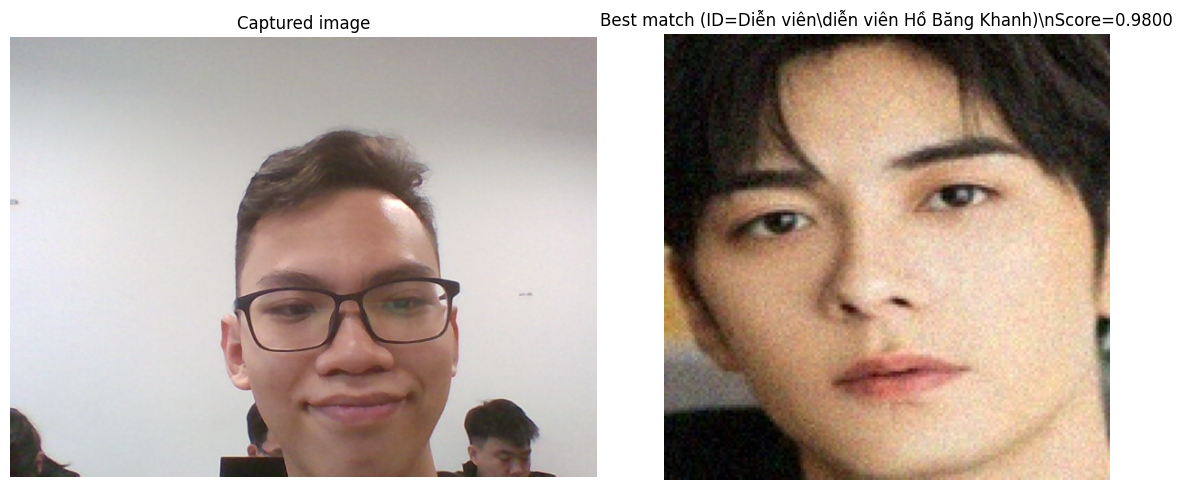

In [129]:
# Step 5: Display results from the latest Step 4 run
if "best_path" not in globals() or best_path is None:
    raise RuntimeError("Missing best match. Run Step 4 first.")

best_bgr = read_image_bgr(best_path)
if best_bgr is None:
    raise RuntimeError("Failed to load best-match image.")

query_rgb = cv2.cvtColor(query_bgr, cv2.COLOR_BGR2RGB)
best_rgb = cv2.cvtColor(best_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(query_rgb)
plt.title("Captured image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(best_rgb)
plt.title(f"Best match (ID={best_label})\\nScore={best_score:.4f}")
plt.axis("off")

plt.tight_layout()
plt.show()